In [1]:
import numpy as np
from scipy.stats import pearsonr
import pandas as pd
from tqdm.auto import tqdm
import itertools
import statsmodels.api as sm
import matplotlib.pyplot as plt
from LSAS.LSAS import alg_LSAS

/Users/fritzwuterich/Documents/Uni/Causal_inference/Thesis/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Generate synthetic data

In [2]:
def generate_dataset_fig4(n, rng):
    nodes_fig4 = [
        "U1", "U2", "U3", "U4",
        "V4", "V7", "V9",
        "V5", "V6", "V2",
        "X", "V8", "V1",
        "Y", "V3"
    ]

    treatment = 'X'
    outcome = 'Y'

    latent_nodes = ["U1", "U2", "U3", "U4"]
    observed_nodes = [n for n in nodes_fig4 if n not in latent_nodes]

    B = pd.DataFrame(0, index=nodes_fig4, columns=nodes_fig4, dtype=float)

    B.loc['U4', 'V5'] = rng.uniform(0.5, 1.5)
    B.loc['U4', 'V6'] = rng.uniform(0.5, 1.5)
    B.loc['V7', 'V6'] = rng.uniform(0.5, 1.5)
    B.loc['V6', 'Y'] = rng.uniform(0.5, 1.5)
    B.loc['V5', 'Y'] = rng.uniform(0.5, 1.5)
    B.loc['U3', 'V5'] = rng.uniform(0.5, 1.5)
    B.loc['U3', 'X'] = rng.uniform(0.5, 1.5)
    B.loc['V2', 'V3'] = rng.uniform(0.5, 1.5)
    B.loc['V2', 'Y'] = rng.uniform(0.5, 1.5)
    B.loc['V9', 'Y'] = rng.uniform(0.5, 1.5)
    B.loc['V9', 'V8'] = rng.uniform(0.5, 1.5)
    B.loc['X', 'Y'] = rng.uniform(0.5, 1.5)
    B.loc['U1', 'V1'] = rng.uniform(0.5, 1.5)
    B.loc['U1', 'X'] = rng.uniform(0.5, 1.5)
    B.loc['U2', 'V1'] = rng.uniform(0.5, 1.5)
    B.loc['U2', 'Y'] = rng.uniform(0.5, 1.5)
    B.loc['V8', 'X'] = rng.uniform(0.5, 1.5)
    B.loc['V8', 'Y'] = rng.uniform(0.5, 1.5)

    E = pd.DataFrame(
        rng.normal(0, 1, size=(n, len(nodes_fig4))),
        columns=nodes_fig4
    )

    D_full = pd.DataFrame(0, index=np.arange(n), columns=nodes_fig4, dtype=float)

    for node in nodes_fig4:
        parents = B.index[B[node] != 0].tolist()
        if len(parents) == 0:
            D_full[node] = E[node].values
        else:
            D_full[node] = D_full[parents].values @ B.loc[parents, node].values + E[node].values

    D_obs = D_full[observed_nodes].copy()

    B_np = B.loc[nodes_fig4, nodes_fig4].values
    total_effect_matrix = np.linalg.inv(np.eye(len(nodes_fig4)) - B_np) - np.eye(len(nodes_fig4))

    x_idx = nodes_fig4.index("X")
    y_idx = nodes_fig4.index("Y")
    true_ce = total_effect_matrix[x_idx, y_idx]

    return D_obs, B, true_ce

## Helper functions

In [3]:
def ci_test(X, Y, Z, D_obs, alpha = 0.05):
    '''
    Returns true if X and Y are conditionally independent given Z, false otherwise.
    '''
    x = D_obs[X].to_numpy(dtype=float)
    y = D_obs[Y].to_numpy(dtype=float)

    if len(Z) == 0:
        stat, p_value = pearsonr(x, y)
        return p_value > alpha, p_value, stat
    
    Z_mat = D_obs[Z].to_numpy(dtype=float)
    Z_mat = np.column_stack([np.ones(len(D_obs)), Z_mat])

    beta_x = np.linalg.lstsq(Z_mat, x, rcond=None)[0]
    beta_y = np.linalg.lstsq(Z_mat, y, rcond=None)[0]

    resid_x = x - Z_mat @ beta_x
    resid_y = y - Z_mat @ beta_y

    stat, p_value = pearsonr(resid_x, resid_y)
    return p_value > alpha, p_value, stat

In [4]:
# run entner rule1 for w , x, y and z 

def r1(w, Z, D_obs, x = 'X', y = 'Y', alpha_dep = 0.01, alpha_indep = 0.1):
    Z = list(Z)
    Z_plus_x = Z + [x]

    indep1, pval1, stat1 = ci_test(w, y, Z, D_obs, alpha_dep)
    indep2, pval2, stat2 = ci_test(w, y, Z_plus_x, D_obs, alpha_indep)

    cond_1 = not indep1
    cond_2 = indep2

    return {
        "R1": cond_1 and cond_2,
        "w": w,
        "Z": list(Z),
        "cond1_dep_given_Z": cond_1,
        "cond2_indep_given_Z_plus_x": cond_2,
        "pval1": pval1,
        "pval2": pval2,
        "stat1": stat1,
        "stat2": stat2
    }

In [5]:
def r2(w, Z, D_obs, x='X', y='Y', alpha_dep=0.01, alpha_indep=0.1):
    Z = list(Z)

    indep1, pval1, stat1 = ci_test(w, x, Z, D_obs, alpha_dep)
    indep2, pval2, stat2 = ci_test(w, y, Z, D_obs, alpha_indep)

    cond_1 = not indep1
    cond_2 = indep2

    return {
        "R2": cond_1 and cond_2,
        "w": w,
        "Z": list(Z),
        "cond1_dep_w_x_given_Z": cond_1,
        "cond2_indep_w_y_given_Z": cond_2,
        "pval1": pval1,
        "pval2": pval2,
        "stat1": stat1,
        "stat2": stat2
    }

In [6]:
def estimate_ate_adjustment(D_obs, x, y, Z):
    """
    Estimate the coefficient of x in a linear regression y ~ x + Z.
    """
    predictors = [x] + list(Z)
    X_mat = sm.add_constant(D_obs[predictors], has_constant="add")
    model = sm.OLS(D_obs[y], X_mat).fit()
    return model.params[x]

In [7]:
def alg_EHS(D_obs, x='X', y='Y', alpha_dep=0.01, alpha_indep=0.1, max_z_size=None):
    W = [col for col in D_obs.columns if col not in [x, y]]
    if max_z_size is None:
        max_z_size = len(W)
    
    VASs = []
    R1_count = 0
    R2_count = 0
    CI_num = 0

    # R2 i)
    for k in range(max_z_size + 1):
        for z in itertools.combinations(W, k):
            indep_xy, _, _ = ci_test(x, y, list(z), D_obs, alpha_indep)
            CI_num += 1
            if indep_xy:
                R2_count += 1

    # R1 i)
    for k in range(max_z_size + 1):
        for Z in itertools.combinations(W, k):
            Z = list(Z)
            for w in W:
                if w in Z:
                    continue
                out_r1 = r1(w, Z, D_obs, x, y, alpha_dep, alpha_indep)
                CI_num += 2

                if out_r1["R1"]:
                    R1_count += 1
                    if Z not in VASs:
                        VASs.append(Z)

                out_r2 = r2(w, Z, D_obs, x, y, alpha_dep, alpha_indep)
                CI_num += 2

                if out_r2["R2"]:
                    R2_count += 1


    if R1_count > 0:
        ates = [estimate_ate_adjustment(D_obs, x, y, Z) for Z in VASs]
        ate = float(np.mean(ates)) if len(ates) > 0 else None
        decision = '+'
    elif R2_count > 0:
        decision = '0'
        ate = 0.0
    else:
        decision = '?'
        ate = None
    return {
        "decision": decision,
        "VASs": VASs,
        "ATE": ate,
        "CI_num": CI_num,
        "R1_count": R1_count,
        "R2_count": R2_count
    }

## Run Experiment

In [8]:
sample_sizes = [1000, 5000, 10000, 15000]
n_reps = 100

results = []
structure_name = "figure4"

treatment = "X"
outcome = "Y"

for n in sample_sizes:
    tqdm.write(f"Running {structure_name} with sample size {n} for {n_reps} reps...")
    for rep in tqdm(range(n_reps), desc=f"Processing {structure_name}", leave=True, position=0):
        D_obs, B, true_ce = generate_dataset_fig4(n, np.random.default_rng(rep))

        # -------- EHS --------
        res = alg_EHS(D_obs, x=treatment, y=outcome, alpha_dep=0.01, alpha_indep=0.1, max_z_size=3)

        decision = res["decision"]
        estimated_ce = res["ATE"]
        nTest = res["CI_num"]
        VASs = res["VASs"]
        R1_count = res["R1_count"]
        R2_count = res["R2_count"]

        RE = None if estimated_ce is None else abs(estimated_ce - true_ce) / abs(true_ce)
        
        results.append({
            "method": "EHS",
            "structure": structure_name,
            "sample_size": n,
            "rep": rep,
            "decision": decision,
            "true_ce": true_ce,
            "estimated_ce": estimated_ce,
            "RE": RE,
            "nTest": nTest,
            "VASs": str(VASs),
            "R1_count": R1_count,
            "R2_count": R2_count
        })


        # -------- LSAS --------
        res_lsas = alg_LSAS(D_obs, Tr_X = treatment, Out_Y = outcome)
        VASs_lsas = res_lsas["VASs"]
        estimated_ce_lsas = res_lsas["ATE"]
        nTest_lsas = res_lsas["CI_num"]

        if VASs_lsas is None:
            decision_lsas = "?"
        elif VASs_lsas == 0:
            decision_lsas = "0"
        else:
            decision_lsas = "+"

        RE_lsas = None if estimated_ce_lsas is None else abs(estimated_ce_lsas - true_ce) / abs(true_ce)

        results.append({
                "method": "LSAS",
                "structure": structure_name,
                "sample_size": n,
                "rep": rep,
                "decision": decision_lsas,
                "true_ce": true_ce,
                "estimated_ce": estimated_ce_lsas,
                "RE": RE_lsas,
                "nTest": nTest_lsas,
                "VASs": str(VASs_lsas),
                "R1_count": None,
                "R2_count": None
            })


results = pd.DataFrame(results)
results.head()

Running figure4 with sample size 1000 for 100 reps...


Processing figure4: 100%|██████████| 100/100 [02:03<00:00,  1.24s/it]


Running figure4 with sample size 5000 for 100 reps...


Processing figure4: 100%|██████████| 100/100 [03:25<00:00,  2.06s/it]


Running figure4 with sample size 10000 for 100 reps...


Processing figure4: 100%|██████████| 100/100 [04:59<00:00,  2.99s/it]


Running figure4 with sample size 15000 for 100 reps...


Processing figure4: 100%|██████████| 100/100 [06:23<00:00,  3.83s/it]


,method,structure,sample_size,rep,decision,true_ce,estimated_ce,RE,nTest,VASs,R1_count,R2_count
0,EHS,figure4,1000,0,+,0.502739,1.299813,1.585465,3478,"[[], ['V4'], ['V7'], ['V9'], ['V6'], ['V2'], [...",64.0,0.0
1,LSAS,figure4,1000,0,?,0.502739,NaN,NaN,553,None,NaN,NaN
2,EHS,figure4,1000,1,?,1.038143,NaN,NaN,3478,[],0.0,0.0
3,LSAS,figure4,1000,1,+,1.038143,1.083002,0.043210,318,"[{'VAS': ['V8', 'V1']}, {'VAS': ['V2', 'V8', '...",NaN,NaN
4,EHS,figure4,1000,2,0,0.650062,0.000000,1.000000,3478,[],0.0,6.0


In [9]:
summary_fig4 = (
    results
    .groupby(['method', "sample_size"], as_index=False)
    .agg(
        mean_RE=("RE", "mean"),
        std_RE=("RE", "std"),
        mean_nTest=("nTest", "mean"),
        std_nTest=("nTest", "std"),
    )
)

summary_fig4

,method,sample_size,mean_RE,std_RE,mean_nTest,std_nTest
0,EHS,1000,0.477331,0.434770,3478.00,0.000000
1,EHS,5000,0.256999,0.400294,3478.00,0.000000
2,EHS,10000,0.177373,0.339594,3478.00,0.000000
3,EHS,15000,0.128258,0.300077,3478.00,0.000000
4,LSAS,1000,0.439963,0.374723,533.25,113.306358
5,LSAS,5000,0.166899,0.184757,562.95,94.415413
6,LSAS,10000,0.114893,0.120584,540.75,98.970292
7,LSAS,15000,0.098952,0.112764,519.65,90.619905


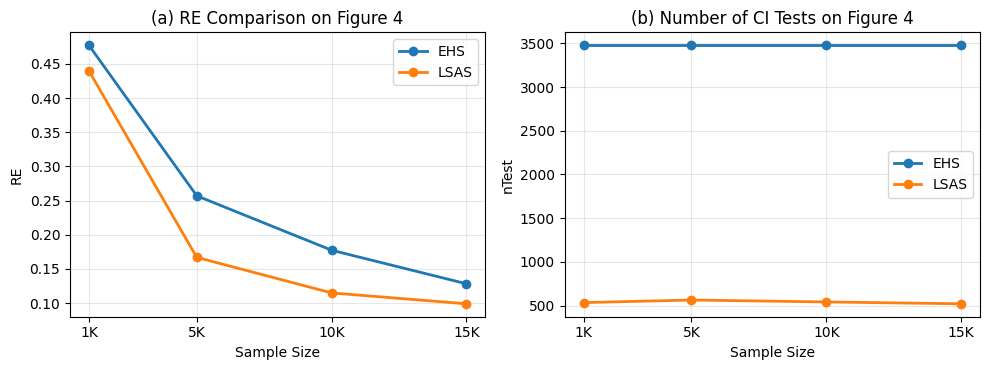

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))

for method in summary_fig4["method"].unique():
    df_method = summary_fig4[summary_fig4["method"] == method]

    # RE panel
    axes[0].plot(
        df_method["sample_size"],
        df_method["mean_RE"],
        marker="o",
        linewidth=2,
        label=method
    )

    # nTest panel
    axes[1].plot(
        df_method["sample_size"],
        df_method["mean_nTest"],
        marker="o",
        linewidth=2,
        label=method
    )

axes[0].set_xlabel("Sample Size")
axes[0].set_ylabel("RE")
axes[0].set_title("(a) RE Comparison on Figure 4")
axes[0].set_xticks(sample_sizes)
axes[0].set_xticklabels(["1K", "5K", "10K", "15K"])
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].set_xlabel("Sample Size")
axes[1].set_ylabel("nTest")
axes[1].set_title("(b) Number of CI Tests on Figure 4")
axes[1].set_xticks(sample_sizes)
axes[1].set_xticklabels(["1K", "5K", "10K", "15K"])
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()